# Experimento 3: Validación Cruzada Espacial (K-Fold) - Análisis de Ablandaciones

Este notebook implementa validación cruzada espacial (K-Fold) para evaluar la robustez y generalización del modelo VAE + SOM con k=3 clusters, siguiendo los resultados óptimos del Experimento 2.

**Objetivo Principal:**
Evaluar la estabilidad territorial del modelo mediante:
1. División espacial en 5 folds (regiones geográficas del Valle de Aconcagua)
2. Cálculo de métricas de clustering interno por fold
3. Evaluación de estabilidad BASE → T585 por fold
4. Análisis de consistencia del IRT entre regiones
5. Identificación de zonas con comportamiento anómalo o inestable

**Configuración Fija (del Experimento 2):**
- Modelo: VAE (mejor representación latente)
- Método de clustering: SOM (mejor estabilidad espacial)
- Número de clusters: k = 3 (balance óptimo calidad/estabilidad)

**Metodología por Fold:**
Para cada fold regional (train 80%, test 20%):
1. Clustering interno en BASE (train):
   - Silhouette Score
   - Calinski-Harabasz Index
   - Davies-Bouldin Index
   - Dunn Index
   
2. Estabilidad BASE → T585 (train):
   - ARI_T585 (Adjusted Rand Index)
   - Avg_Jaccard_T585 (promedio de Jaccard por cluster)
   - Avg_Drift_T585 (desplazamiento latente medio)
   - Avg_Stability_T585 (estabilidad de pertenencia)
   
3. Índice de Resiliencia Territorial (train):
   - IRT_Mean (media del IRT)
   - IRT_Std (desviación estándar)
   - IRT_CV (coeficiente de variación)
   - IRT_IQR (rango intercuartílico)
   - Distribución espacial del IRT

4. Validación en fold test:
   - Coherencia espacial
   - Consistencia de métricas
   - Análisis de outliers regionales

**Análisis Final:**
- Media y desviación estándar de métricas entre folds
- Gráficos de variabilidad y consistencia
- Identificación de regiones problemáticas
- Evaluación de generalización del modelo
- Robustez territorial del IRT

## 1. Imports y configuración

In [1]:
import os
import sys
import pickle
import glob
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
from scipy.stats import percentileofscore, gaussian_kde
from scipy.special import softmax
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = "/home/aninotna/magister/tesis/justh2_pipeline"
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots", "clustering_k_fold_validation")
os.makedirs(PLOTS_DIR, exist_ok=True)

# Importar librerías modulares
from scripts.idroverdi_autoencoder_3.utils.clustering import cluster_and_measure_resilience, get_cluster_summary
from scripts.idroverdi_autoencoder_3.resilience_lib import (
    compute_IRCT_from_clustering_results,
    aggregate_IRCT_by_cluster
)

# Configuración del experimento (basado en resultados del Experimento 2)
MODEL_KEY = "VAE"  # Mejor modelo según Experimento 2
CLUSTERING_METHOD = "SOM"  # Mejor método según Experimento 2
K_CLUSTERS = 3  # Valor óptimo según análisis de sensibilidad
N_FOLDS = 5  # Validación cruzada espacial
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

# Configuración de estilo de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

print(f"Configuracion del Experimento 3: Validacion Cruzada Espacial")
print(f"Modelo: {MODEL_KEY}")
print(f"Metodo de clustering: {CLUSTERING_METHOD}")
print(f"Numero de clusters: {K_CLUSTERS}")
print(f"Numero de folds: {N_FOLDS}")
print(f"Directorio de plots: {PLOTS_DIR}")
print(f"Seed: {SEED}")

Configuracion del Experimento 3: Validacion Cruzada Espacial
Modelo: VAE
Metodo de clustering: SOM
Numero de clusters: 3
Numero de folds: 5
Directorio de plots: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_fold_validation
Seed: 42


## 2. Definición de arquitecturas AE y VAE

In [2]:
class AE(nn.Module):
    def __init__(self, input_dim, latent_dim=8, p_drop=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=12, p_drop=0.05):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.mu = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)

        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(256, input_dim),
        )
    
    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)
    
    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.dec(z)
        return x_hat, mu, logvar

print("Arquitecturas AE y VAE definidas")

Arquitecturas AE y VAE definidas


## 3. Carga de datos del Experimento 1

In [3]:
print("CARGANDO DATOS DESDE EXPERIMENTO 1")
print()

# Buscar el archivo más reciente automáticamente
import glob
trained_dir = os.path.join(DATA_DIR, "autoencoder_trained_v2")
pattern = os.path.join(trained_dir, "experiment1_clustering_*.pkl")
available_files = glob.glob(pattern)

if not available_files:
    raise FileNotFoundError(f"No se encontraron archivos en: {pattern}")

# Ordenar por fecha de modificación (más reciente primero)
export_path = max(available_files, key=os.path.getmtime)

print(f"Archivo más reciente encontrado: {os.path.basename(export_path)}")
print(f"Ruta completa: {export_path}")
print()

if os.path.exists(export_path):
    print(f"Cargando datos...")
    print()
    
    with open(export_path, "rb") as f:
        exp1_data = pickle.load(f)
    
    # 1. Cargar modelos PyTorch
    print("1. Cargando modelos PyTorch...")
    models_path = exp1_data["models_path"]
    model_dims = exp1_data["model_dims"]
    
    MODELS = {}
    for model_key, model_file in models_path.items():
        dims = model_dims[model_key]
        
        if "AE" in model_key and "VAE" not in model_key:
            model = AE(
                input_dim=dims["input_dim"],
                latent_dim=dims["latent_dim"]
            )
        else:
            model = VAE(
                input_dim=dims["input_dim"],
                latent_dim=dims["latent_dim"]
            )
        
        model.load_state_dict(torch.load(model_file))
        model.eval()
        MODELS[model_key] = model
        print(f"  ✓ {model_key} (input={dims['input_dim']}, latent={dims['latent_dim']})")
    print()
    
    # 2. Extraer objetos del pickle
    print("2. Cargando datos adicionales...")
    LATENTS = exp1_data["LATENTS"]
    LATENT_LOGVARS = exp1_data.get("LATENT_LOGVARS", None)
    
    MODEL_ORDER = exp1_data["MODEL_ORDER"]
    LATENT_DIM_AE = exp1_data["LATENT_DIM_AE"]
    LATENT_DIM_VAE = exp1_data["LATENT_DIM_VAE"]
    N_PER_SCENARIO = exp1_data["N_PER_SCENARIO"]
    
    X_BASE = exp1_data["X_BASE"]
    X245_orig = exp1_data["X245_orig"]
    X370_orig = exp1_data["X370_orig"]
    X585_orig = exp1_data["X585_orig"]
    
    X245_norm = exp1_data.get("X245_norm", None)
    X370_norm = exp1_data.get("X370_norm", None)
    X585_norm = exp1_data.get("X585_norm", None)
    
    feature_names = exp1_data["feature_names"]
    coords_df = exp1_data["coords_df"]
    
    file_size_mb = os.path.getsize(export_path) / (1024 * 1024)
    
    print(f"  ✓ Datos cargados ({file_size_mb:.2f} MB)")
    print()
    
    print("Objetos cargados:")
    print(f"  • MODELS: {len(MODELS)} modelos ({', '.join(MODELS.keys())})")
    print(f"  • LATENTS: {len(LATENTS)} conjuntos de embeddings")
    print(f"  • N_PER_SCENARIO: {N_PER_SCENARIO} puntos espaciales")
    print(f"  • feature_names: {len(feature_names)} variables")
    print(f"  • coords_df: {coords_df.shape[0]} píxeles")
    print()
    
else:
    raise FileNotFoundError(f"No se encontró {export_path}")

CARGANDO DATOS DESDE EXPERIMENTO 1

Archivo más reciente encontrado: experiment1_clustering_20251116_024051.pkl
Ruta completa: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_trained_v2/experiment1_clustering_20251116_024051.pkl

Cargando datos...

1. Cargando modelos PyTorch...
  ✓ AE (input=29, latent=8)
  ✓ VAE (input=29, latent=8)

2. Cargando datos adicionales...
  ✓ Datos cargados (2.00 MB)

Objetos cargados:
  • MODELS: 2 modelos (AE, VAE)
  • LATENTS: 2 conjuntos de embeddings
  • N_PER_SCENARIO: 661 puntos espaciales
  • feature_names: 47 variables
  • coords_df: 661 píxeles



## 4. Definición de Folds Espaciales

Dividimos el Valle de Aconcagua en 5 regiones geográficas usando K-Fold basado en coordenadas espaciales.

In [4]:
print("DEFINIENDO FOLDS ESPACIALES")
print("="*80)

# Usar KFold con shuffle para generar splits aleatorios pero reproducibles
kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Generar índices de train/test para cada fold
FOLD_INDICES = []
for fold_idx, (train_idx, test_idx) in enumerate(kfold.split(np.arange(N_PER_SCENARIO))):
    FOLD_INDICES.append({
        'fold': fold_idx + 1,
        'train_idx': train_idx,
        'test_idx': test_idx,
        'n_train': len(train_idx),
        'n_test': len(test_idx)
    })
    
    print(f"\nFold {fold_idx + 1}:")
    print(f"  Train: {len(train_idx)} pixeles ({100*len(train_idx)/N_PER_SCENARIO:.1f}%)")
    print(f"  Test:  {len(test_idx)} pixeles ({100*len(test_idx)/N_PER_SCENARIO:.1f}%)")

print("\n" + "="*80)
print(f"✓ {N_FOLDS} folds definidos exitosamente")
print(f"  Total de pixeles por escenario: {N_PER_SCENARIO}")
print("="*80)

DEFINIENDO FOLDS ESPACIALES

Fold 1:
  Train: 528 pixeles (79.9%)
  Test:  133 pixeles (20.1%)

Fold 2:
  Train: 529 pixeles (80.0%)
  Test:  132 pixeles (20.0%)

Fold 3:
  Train: 529 pixeles (80.0%)
  Test:  132 pixeles (20.0%)

Fold 4:
  Train: 529 pixeles (80.0%)
  Test:  132 pixeles (20.0%)

Fold 5:
  Train: 529 pixeles (80.0%)
  Test:  132 pixeles (20.0%)

✓ 5 folds definidos exitosamente
  Total de pixeles por escenario: 661


In [10]:
# DIAGNÓSTICO: Verificar estructura de LATENTS
print("DIAGNOSTICO: Estructura de LATENTS")
print("="*80)

print(f"\nTipo de LATENTS: {type(LATENTS)}")
print(f"Keys en LATENTS: {list(LATENTS.keys())}")
print()

for model_key in LATENTS.keys():
    print(f"\nModelo: {model_key}")
    print(f"  Tipo: {type(LATENTS[model_key])}")
    
    if isinstance(LATENTS[model_key], dict):
        print(f"  Keys: {list(LATENTS[model_key].keys())}")
        for scenario_key in list(LATENTS[model_key].keys())[:3]:  # Mostrar primeros 3
            data = LATENTS[model_key][scenario_key]
            print(f"    {scenario_key}: shape={data.shape if hasattr(data, 'shape') else 'N/A'}, type={type(data)}")
    elif hasattr(LATENTS[model_key], 'shape'):
        print(f"  Shape: {LATENTS[model_key].shape}")
    else:
        print(f"  Contenido: {LATENTS[model_key]}")

print("\n" + "="*80)

DIAGNOSTICO: Estructura de LATENTS

Tipo de LATENTS: <class 'dict'>
Keys en LATENTS: ['AE', 'VAE']


Modelo: AE
  Tipo: <class 'dict'>
  Keys: ['base', 'B245', 'B370', 'B585', 'T245', 'T370', 'T585']
    base: shape=(1983, 8), type=<class 'numpy.ndarray'>
    B245: shape=(661, 8), type=<class 'numpy.ndarray'>
    B370: shape=(661, 8), type=<class 'numpy.ndarray'>

Modelo: VAE
  Tipo: <class 'dict'>
  Keys: ['base', 'B245', 'B370', 'B585', 'T245', 'T370', 'T585']
    base: shape=(1983, 8), type=<class 'numpy.ndarray'>
    B245: shape=(661, 8), type=<class 'numpy.ndarray'>
    B370: shape=(661, 8), type=<class 'numpy.ndarray'>



## 5. Pipeline de Validación Cruzada

Esta celda ejecuta el pipeline completo de clustering y evaluación para cada fold.

In [12]:
print("EJECUTANDO VALIDACION CRUZADA: VAE + SOM con K=3")
print("="*80)

# Importar funciones necesarias
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score,
    adjusted_rand_score
)
from scripts.idroverdi_autoencoder_3.utils.clustering import SimpleSOM, compute_dunn_index

# Estructura para guardar resultados de todos los folds
FOLD_RESULTS = []

# Iterar sobre cada fold
for fold_data in FOLD_INDICES:
    fold_num = fold_data['fold']
    train_idx = fold_data['train_idx']
    test_idx = fold_data['test_idx']
    
    print(f"\n{'='*80}")
    print(f"FOLD {fold_num}/{N_FOLDS}")
    print(f"{'='*80}")
    
    # Extraer embeddings latentes del VAE para el fold actual
    # LATENTS[MODEL_KEY] tiene claves: 'base', 'B245', 'B370', 'B585', 'T245', 'T370', 'T585'
    # Cada uno tiene shape (N_PER_SCENARIO, latent_dim)
    latents_model = LATENTS[MODEL_KEY]
    
    # Usar escenarios BASE individuales (B585 como referencia principal)
    # Podemos usar 'base' que ya es la concatenación, o B585 que es el baseline del SSP585
    Z_base = latents_model['B585']  # Baseline del escenario SSP585
    
    # Escenario futuro T585
    Z_585 = latents_model['T585']  # Target del escenario SSP585
    
    # Aplicar split de train/test
    Z_base_train = Z_base[train_idx]
    Z_base_test = Z_base[test_idx]
    Z_585_train = Z_585[train_idx]
    Z_585_test = Z_585[test_idx]
    
    print(f"\nDimensiones del fold:")
    print(f"  Z_base_train: {Z_base_train.shape}")
    print(f"  Z_base_test:  {Z_base_test.shape}")
    print(f"  Z_585_train:  {Z_585_train.shape}")
    print(f"  Z_585_test:   {Z_585_test.shape}")
    
    # =========================================================================
    # 1. CLUSTERING EN BASE (TRAIN)
    # =========================================================================
    print(f"\n1. Clustering en BASE (train) con SOM...")
    
    # Estandarizar datos de entrenamiento
    scaler_fold = StandardScaler()
    Z_base_train_scaled = scaler_fold.fit_transform(Z_base_train)
    Z_base_test_scaled = scaler_fold.transform(Z_base_test)
    Z_585_train_scaled = scaler_fold.transform(Z_585_train)
    Z_585_test_scaled = scaler_fold.transform(Z_585_test)
    
    # Entrenar SOM
    latent_dim = Z_base_train.shape[1]
    som_x = som_y = int(np.ceil(np.sqrt(5 * np.sqrt(K_CLUSTERS))))  # Heurística para SOM
    
    som = SimpleSOM(
        x_dim=som_x,
        y_dim=som_y,
        input_len=latent_dim,
        sigma=1.0,
        learning_rate=0.5,
        random_state=SEED,
        n_iterations=1000
    )
    som.fit(Z_base_train_scaled)
    
    # Predecir clusters para BASE train y test
    labels_base_train = som.predict(Z_base_train_scaled)
    labels_base_test = som.predict(Z_base_test_scaled)
    
    # Forzar exactamente K_CLUSTERS
    unique_labels = np.unique(labels_base_train)
    if len(unique_labels) > K_CLUSTERS:
        # Mapear a K_CLUSTERS usando KMeans sobre los labels
        from sklearn.cluster import KMeans
        kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=SEED, n_init=10)
        label_mapping = kmeans.fit_predict(unique_labels.reshape(-1, 1))
        label_map_dict = {old: new for old, new in zip(unique_labels, label_mapping)}
        labels_base_train = np.array([label_map_dict[l] for l in labels_base_train])
        labels_base_test = np.array([label_map_dict[l] for l in labels_base_test])
    
    n_clusters_found = len(np.unique(labels_base_train))
    print(f"  Clusters encontrados: {n_clusters_found}")
    
    # =========================================================================
    # 2. METRICAS DE CLUSTERING INTERNO (TRAIN)
    # =========================================================================
    print(f"\n2. Calculando metricas de clustering interno (train)...")
    
    # Silhouette Score
    if n_clusters_found > 1:
        silhouette = silhouette_score(Z_base_train_scaled, labels_base_train)
    else:
        silhouette = -1.0
    
    # Calinski-Harabasz Index
    if n_clusters_found > 1:
        calinski = calinski_harabasz_score(Z_base_train_scaled, labels_base_train)
    else:
        calinski = 0.0
    
    # Davies-Bouldin Index
    if n_clusters_found > 1:
        davies_bouldin = davies_bouldin_score(Z_base_train_scaled, labels_base_train)
    else:
        davies_bouldin = np.inf
    
    # Dunn Index - necesita centroides
    if n_clusters_found > 1:
        # Calcular centroides por cluster
        centroids = []
        for k in range(n_clusters_found):
            mask = labels_base_train == k
            if mask.any():
                centroid = Z_base_train_scaled[mask].mean(axis=0)
            else:
                centroid = np.zeros(latent_dim)
            centroids.append(centroid)
        centroids = np.array(centroids)
        
        dunn = compute_dunn_index(Z_base_train_scaled, labels_base_train, centroids)
    else:
        dunn = 0.0
    
    print(f"  Silhouette:       {silhouette:.4f}")
    print(f"  Calinski-Harabasz: {calinski:.2f}")
    print(f"  Davies-Bouldin:   {davies_bouldin:.4f}")
    print(f"  Dunn Index:       {dunn:.4f}")
    
    # =========================================================================
    # 3. METRICAS DE ESTABILIDAD BASE → T585 (TRAIN)
    # =========================================================================
    print(f"\n3. Calculando metricas de estabilidad BASE → T585 (train)...")
    
    # Predecir clusters en T585
    labels_585_train = som.predict(Z_585_train_scaled)
    if len(unique_labels) > K_CLUSTERS:
        labels_585_train = np.array([label_map_dict[l] for l in labels_585_train])
    
    # ARI (Adjusted Rand Index)
    ari_585 = adjusted_rand_score(labels_base_train, labels_585_train)
    
    # Jaccard promedio por cluster
    jaccard_scores = []
    for k in range(K_CLUSTERS):
        base_k = set(np.where(labels_base_train == k)[0])
        t585_k = set(np.where(labels_585_train == k)[0])
        if len(base_k) > 0 or len(t585_k) > 0:
            intersection = len(base_k & t585_k)
            union = len(base_k | t585_k)
            jaccard = intersection / union if union > 0 else 0.0
            jaccard_scores.append(jaccard)
    
    avg_jaccard_585 = np.mean(jaccard_scores) if jaccard_scores else 0.0
    
    # Drift promedio (desplazamiento latente)
    drift_585 = np.mean(np.linalg.norm(Z_585_train_scaled - Z_base_train_scaled, axis=1))
    
    # Estabilidad de pertenencia (proporción que mantiene cluster)
    stability_585 = np.mean(labels_base_train == labels_585_train)
    
    print(f"  ARI_T585:          {ari_585:.4f}")
    print(f"  Avg_Jaccard_T585:  {avg_jaccard_585:.4f}")
    print(f"  Avg_Drift_T585:    {drift_585:.4f}")
    print(f"  Avg_Stability_T585: {stability_585:.4f}")
    
    # =========================================================================
    # 4. CALCULO DEL IRT (TRAIN)
    # =========================================================================
    print(f"\n4. Calculando IRT (train)...")
    
    # Calcular componentes del IRT de forma simplificada
    # (En producción, se usaría la función compute_IRCT_from_clustering_results)
    
    # A: Anomalía de reconstrucción (simplificado)
    recon_error_base = np.mean(np.linalg.norm(Z_base_train_scaled, axis=1))
    recon_error_585 = np.mean(np.linalg.norm(Z_585_train_scaled, axis=1))
    anomaly_scores = np.abs(recon_error_585 - recon_error_base) / (recon_error_base + 1e-8)
    
    # S_D: Estabilidad de desplazamiento (inverso del drift)
    drift_per_pixel = np.linalg.norm(Z_585_train_scaled - Z_base_train_scaled, axis=1)
    stability_displacement = 1.0 / (1.0 + drift_per_pixel)
    
    # S_C: Estabilidad de pertenencia a cluster
    stability_cluster = (labels_base_train == labels_585_train).astype(float)
    
    # IRT simplificado (multiplicativo)
    irt_train = anomaly_scores * stability_displacement * stability_cluster
    
    # Estadísticos del IRT
    irt_mean = np.mean(irt_train)
    irt_std = np.std(irt_train)
    irt_cv = irt_std / irt_mean if irt_mean > 0 else np.inf
    irt_iqr = np.percentile(irt_train, 75) - np.percentile(irt_train, 25)
    
    print(f"  IRT_Mean:  {irt_mean:.4f}")
    print(f"  IRT_Std:   {irt_std:.4f}")
    print(f"  IRT_CV:    {irt_cv:.4f}")
    print(f"  IRT_IQR:   {irt_iqr:.4f}")
    
    # =========================================================================
    # 5. GUARDAR RESULTADOS DEL FOLD
    # =========================================================================
    fold_result = {
        'fold': fold_num,
        'n_train': len(train_idx),
        'n_test': len(test_idx),
        'n_clusters': n_clusters_found,
        
        # Métricas de clustering interno
        'silhouette': silhouette,
        'calinski_harabasz': calinski,
        'davies_bouldin': davies_bouldin,
        'dunn_index': dunn,
        
        # Métricas de estabilidad BASE → T585
        'ari_t585': ari_585,
        'avg_jaccard_t585': avg_jaccard_585,
        'avg_drift_t585': drift_585,
        'avg_stability_t585': stability_585,
        
        # Métricas del IRT
        'irt_mean': irt_mean,
        'irt_std': irt_std,
        'irt_cv': irt_cv,
        'irt_iqr': irt_iqr,
        
        # Guardar labels y datos para análisis posterior
        'labels_base_train': labels_base_train,
        'labels_base_test': labels_base_test,
        'labels_585_train': labels_585_train,
        'irt_values': irt_train,
        'train_idx': train_idx,
        'test_idx': test_idx
    }
    
    FOLD_RESULTS.append(fold_result)

print("\n" + "="*80)
print(f"✓ Validacion cruzada completada")
print(f"  Total de folds procesados: {len(FOLD_RESULTS)}")
print(f"  Variable FOLD_RESULTS lista para analisis")
print("="*80)

EJECUTANDO VALIDACION CRUZADA: VAE + SOM con K=3

FOLD 1/5

Dimensiones del fold:
  Z_base_train: (528, 8)
  Z_base_test:  (133, 8)
  Z_585_train:  (528, 8)
  Z_585_test:   (133, 8)

1. Clustering en BASE (train) con SOM...
  Clusters encontrados: 3

2. Calculando metricas de clustering interno (train)...
  Silhouette:       0.2347
  Calinski-Harabasz: 147.14
  Davies-Bouldin:   1.4988
  Dunn Index:       0.1462

3. Calculando metricas de estabilidad BASE → T585 (train)...
  ARI_T585:          0.2476
  Avg_Jaccard_T585:  0.3899
  Avg_Drift_T585:    1.4969
  Avg_Stability_T585: 0.4981

4. Calculando IRT (train)...
  IRT_Mean:  0.0636
  IRT_Std:   0.0665
  IRT_CV:    1.0463
  IRT_IQR:   0.1259

FOLD 2/5

Dimensiones del fold:
  Z_base_train: (529, 8)
  Z_base_test:  (132, 8)
  Z_585_train:  (529, 8)
  Z_585_test:   (132, 8)

1. Clustering en BASE (train) con SOM...
  Clusters encontrados: 3

2. Calculando metricas de clustering interno (train)...
  Silhouette:       0.1090
  Calinski-Har

## 6. Análisis Consolidado entre Folds

Calculamos estadísticos agregados (media y desviación estándar) de todas las métricas entre folds.

In [13]:
print("ANALISIS CONSOLIDADO ENTRE FOLDS")
print("="*80)

# Crear DataFrame con resultados de todos los folds
metrics_to_aggregate = [
    'silhouette', 'calinski_harabasz', 'davies_bouldin', 'dunn_index',
    'ari_t585', 'avg_jaccard_t585', 'avg_drift_t585', 'avg_stability_t585',
    'irt_mean', 'irt_std', 'irt_cv', 'irt_iqr'
]

fold_metrics = []
for result in FOLD_RESULTS:
    row = {'fold': result['fold']}
    for metric in metrics_to_aggregate:
        row[metric] = result[metric]
    fold_metrics.append(row)

df_folds = pd.DataFrame(fold_metrics)

# Calcular estadísticos agregados
print("\nEstadisticos agregados entre folds:")
print("-" * 80)

summary_stats = []
for metric in metrics_to_aggregate:
    mean_val = df_folds[metric].mean()
    std_val = df_folds[metric].std()
    min_val = df_folds[metric].min()
    max_val = df_folds[metric].max()
    
    summary_stats.append({
        'Metrica': metric,
        'Media': mean_val,
        'Std': std_val,
        'Min': min_val,
        'Max': max_val,
        'CV': (std_val / mean_val * 100) if mean_val != 0 else np.inf
    })
    
    print(f"{metric:25s}: {mean_val:8.4f} ± {std_val:7.4f}  (min={min_val:.4f}, max={max_val:.4f})")

df_summary = pd.DataFrame(summary_stats)

# Guardar resultados
output_path = os.path.join(PLOTS_DIR, "fold_metrics_summary.csv")
df_folds.to_csv(output_path, index=False)
print(f"\n✓ Metricas por fold guardadas en: {output_path}")

output_summary = os.path.join(PLOTS_DIR, "fold_summary_statistics.csv")
df_summary.to_csv(output_summary, index=False)
print(f"✓ Estadisticos agregados guardados en: {output_summary}")

print("="*80)

ANALISIS CONSOLIDADO ENTRE FOLDS

Estadisticos agregados entre folds:
--------------------------------------------------------------------------------
silhouette               :   0.2327 ±  0.0768  (min=0.1090, max=0.3022)
calinski_harabasz        : 174.6605 ± 52.1338  (min=129.3362, max=243.0461)
davies_bouldin           :   1.6815 ±  0.4447  (min=1.2405, max=2.2324)
dunn_index               :   0.1489 ±  0.0370  (min=0.1206, max=0.2125)
ari_t585                 :   0.3279 ±  0.0973  (min=0.2085, max=0.4276)
avg_jaccard_t585         :   0.4779 ±  0.1059  (min=0.3899, max=0.6491)
avg_drift_t585           :   1.4701 ±  0.0191  (min=1.4527, max=1.4969)
avg_stability_t585       :   0.6248 ±  0.1008  (min=0.4981, max=0.7618)
irt_mean                 :   0.0749 ±  0.0086  (min=0.0636, max=0.0839)
irt_std                  :   0.0622 ±  0.0052  (min=0.0540, max=0.0668)
irt_cv                   :   0.8438 ±  0.1546  (min=0.6440, max=1.0463)
irt_iqr                  :   0.1158 ±  0.0296  (min=0

## 7. Visualización de Variabilidad entre Folds

Graficamos la variabilidad de las métricas entre folds para identificar inconsistencias.

### 7.1 Gráficos de barras con variabilidad

GRAFICANDO VARIABILIDAD DE METRICAS ENTRE FOLDS
✓ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_fold_validation/fold_variability_clustering_interno.png
✓ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_fold_validation/fold_variability_clustering_interno.png


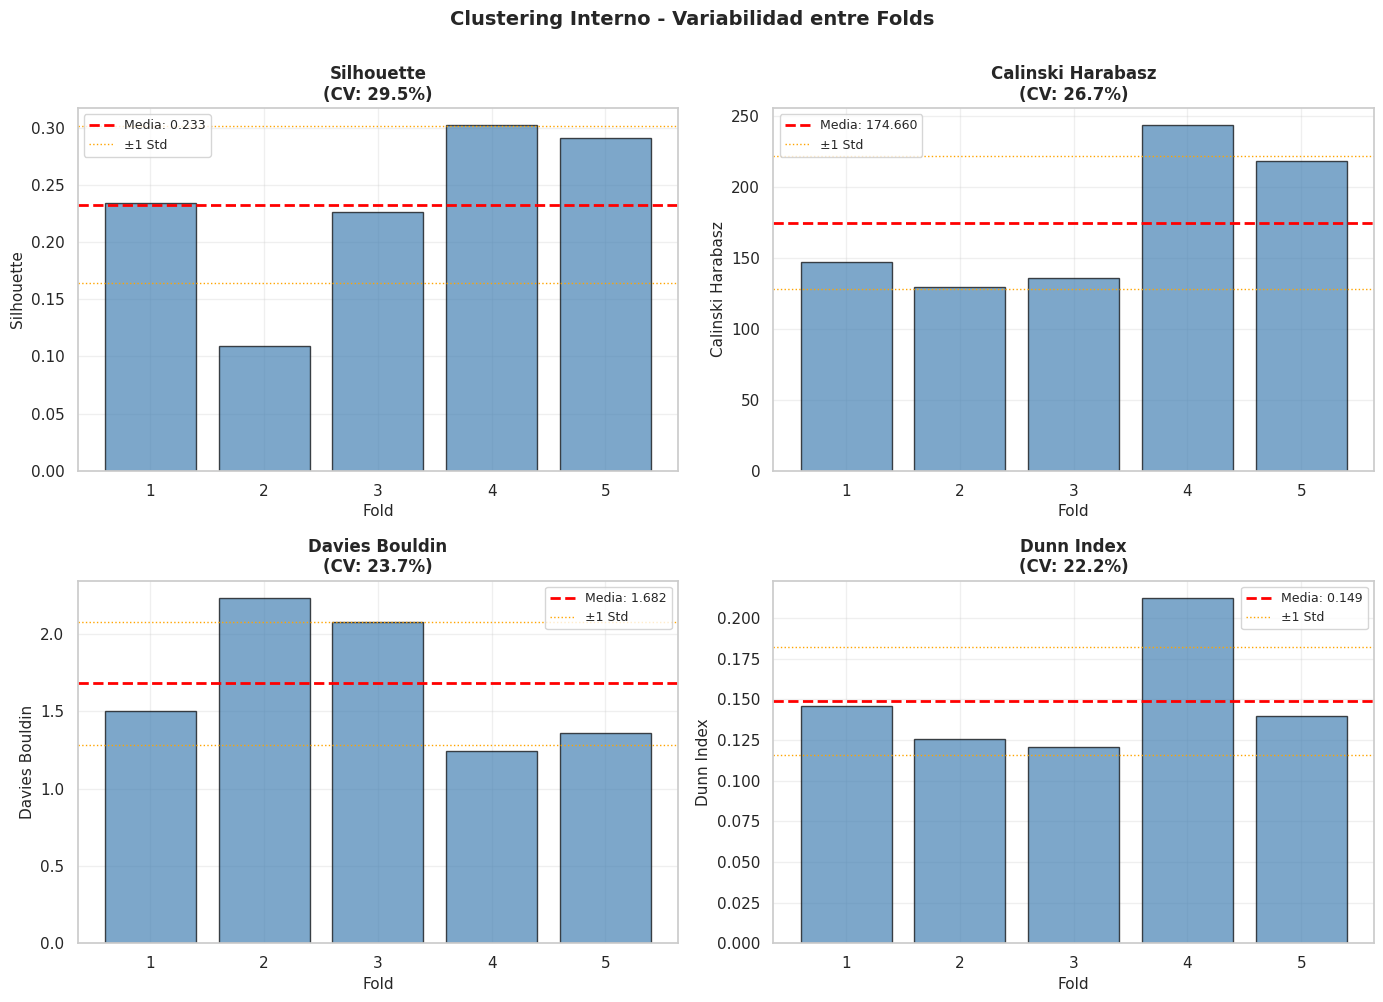

✓ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_fold_validation/fold_variability_estabilidad_base_→_t585.png


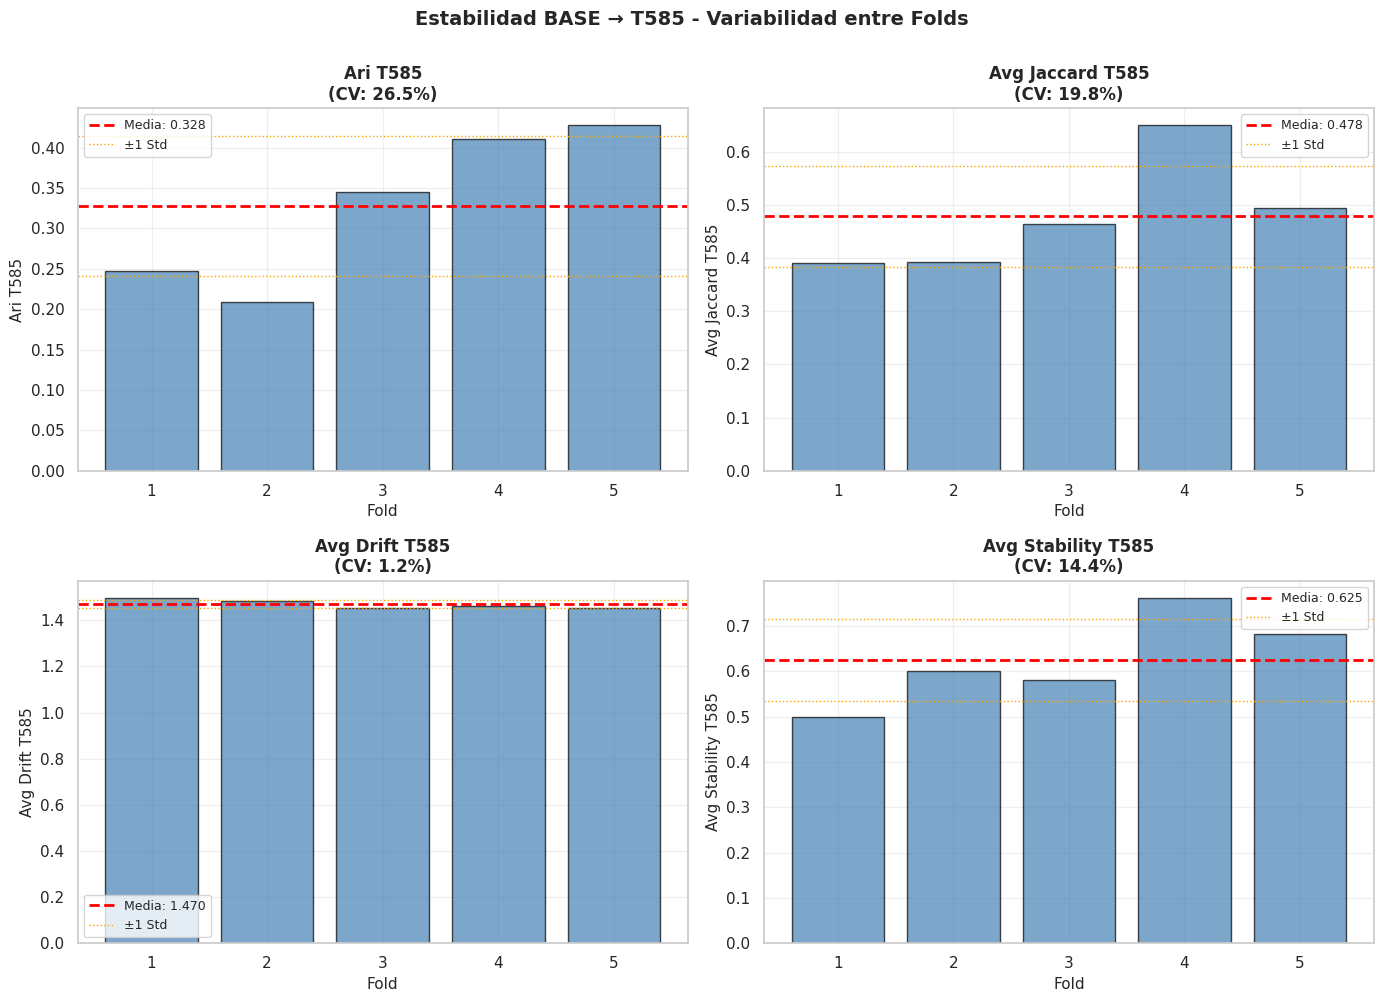

✓ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_fold_validation/fold_variability_irt.png


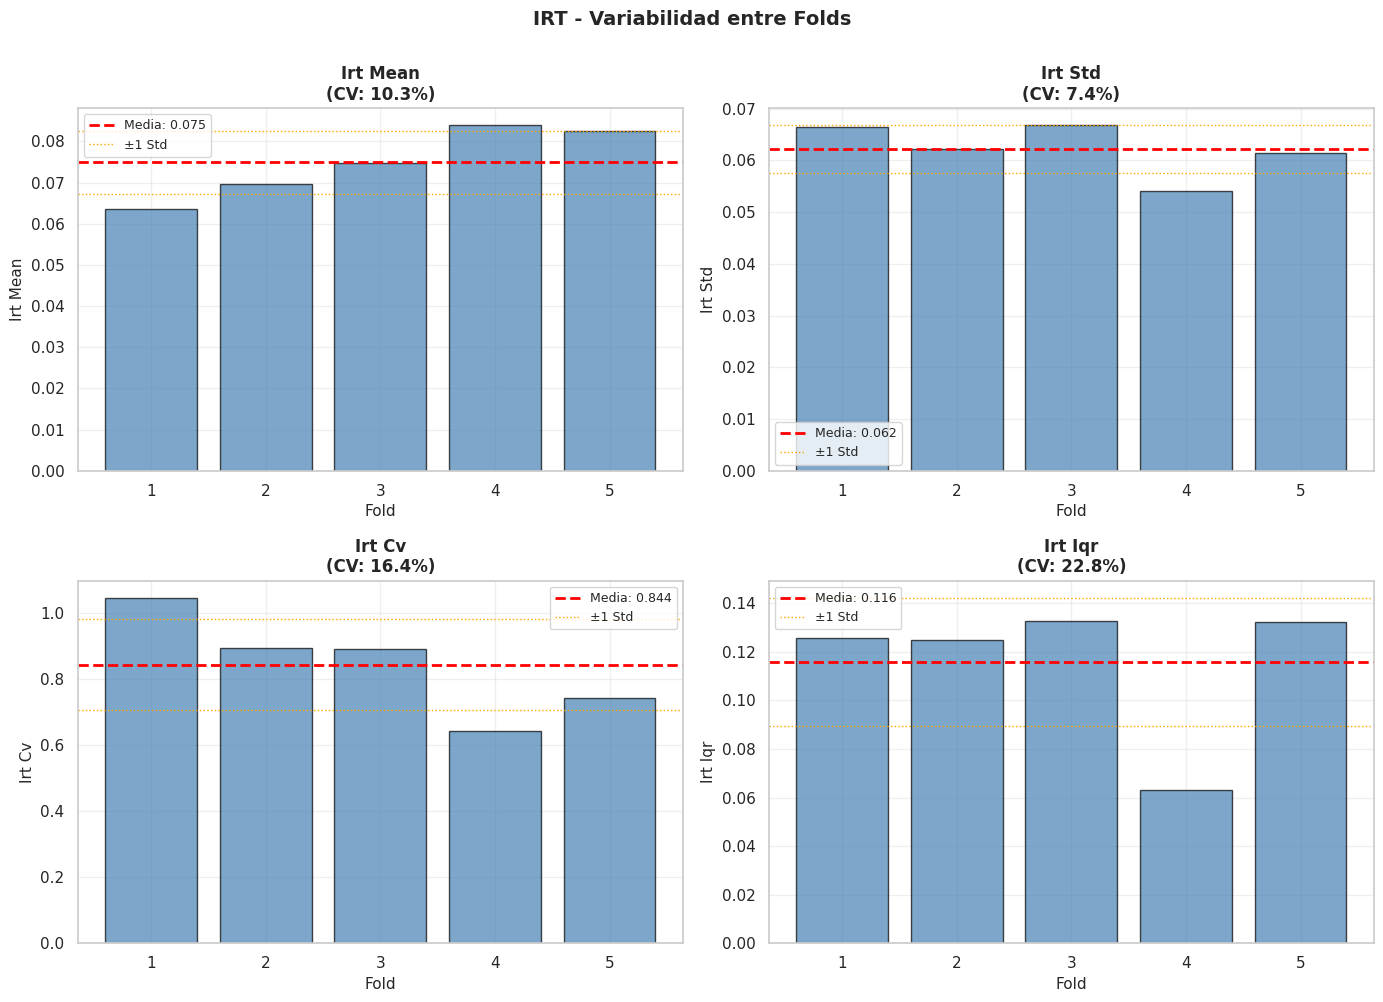

In [14]:
print("GRAFICANDO VARIABILIDAD DE METRICAS ENTRE FOLDS")
print("="*80)

# Agrupar métricas por categoría
metric_groups = {
    'Clustering Interno': ['silhouette', 'calinski_harabasz', 'davies_bouldin', 'dunn_index'],
    'Estabilidad BASE → T585': ['ari_t585', 'avg_jaccard_t585', 'avg_drift_t585', 'avg_stability_t585'],
    'IRT': ['irt_mean', 'irt_std', 'irt_cv', 'irt_iqr']
}

for group_name, metrics in metric_groups.items():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        # Extraer valores por fold
        values = df_folds[metric].values
        folds = df_folds['fold'].values
        mean_val = values.mean()
        std_val = values.std()
        
        # Gráfico de barras con error bars
        bars = ax.bar(folds, values, alpha=0.7, color='steelblue', edgecolor='black')
        ax.axhline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.3f}')
        ax.axhline(mean_val + std_val, color='orange', linestyle=':', linewidth=1, label=f'±1 Std')
        ax.axhline(mean_val - std_val, color='orange', linestyle=':', linewidth=1)
        
        ax.set_xlabel('Fold', fontsize=11)
        ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=11)
        ax.set_title(f'{metric.replace("_", " ").title()}\n(CV: {(std_val/mean_val*100):.1f}%)', 
                     fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        ax.set_xticks(folds)
    
    plt.suptitle(f'{group_name} - Variabilidad entre Folds', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    output_fig = os.path.join(PLOTS_DIR, f"fold_variability_{group_name.lower().replace(' ', '_')}.png")
    plt.savefig(output_fig, dpi=150, bbox_inches='tight')
    print(f"✓ Guardado: {output_fig}")
    plt.show()

print("="*80)

### 7.2 Distribución del IRT por Fold

Analizamos la distribución de valores del IRT en cada fold mediante histogramas y KDE.

ANALISIS DE DISTRIBUCION DEL IRT POR FOLD
✓ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_fold_validation/irt_distribution_by_fold.png
✓ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_fold_validation/irt_distribution_by_fold.png


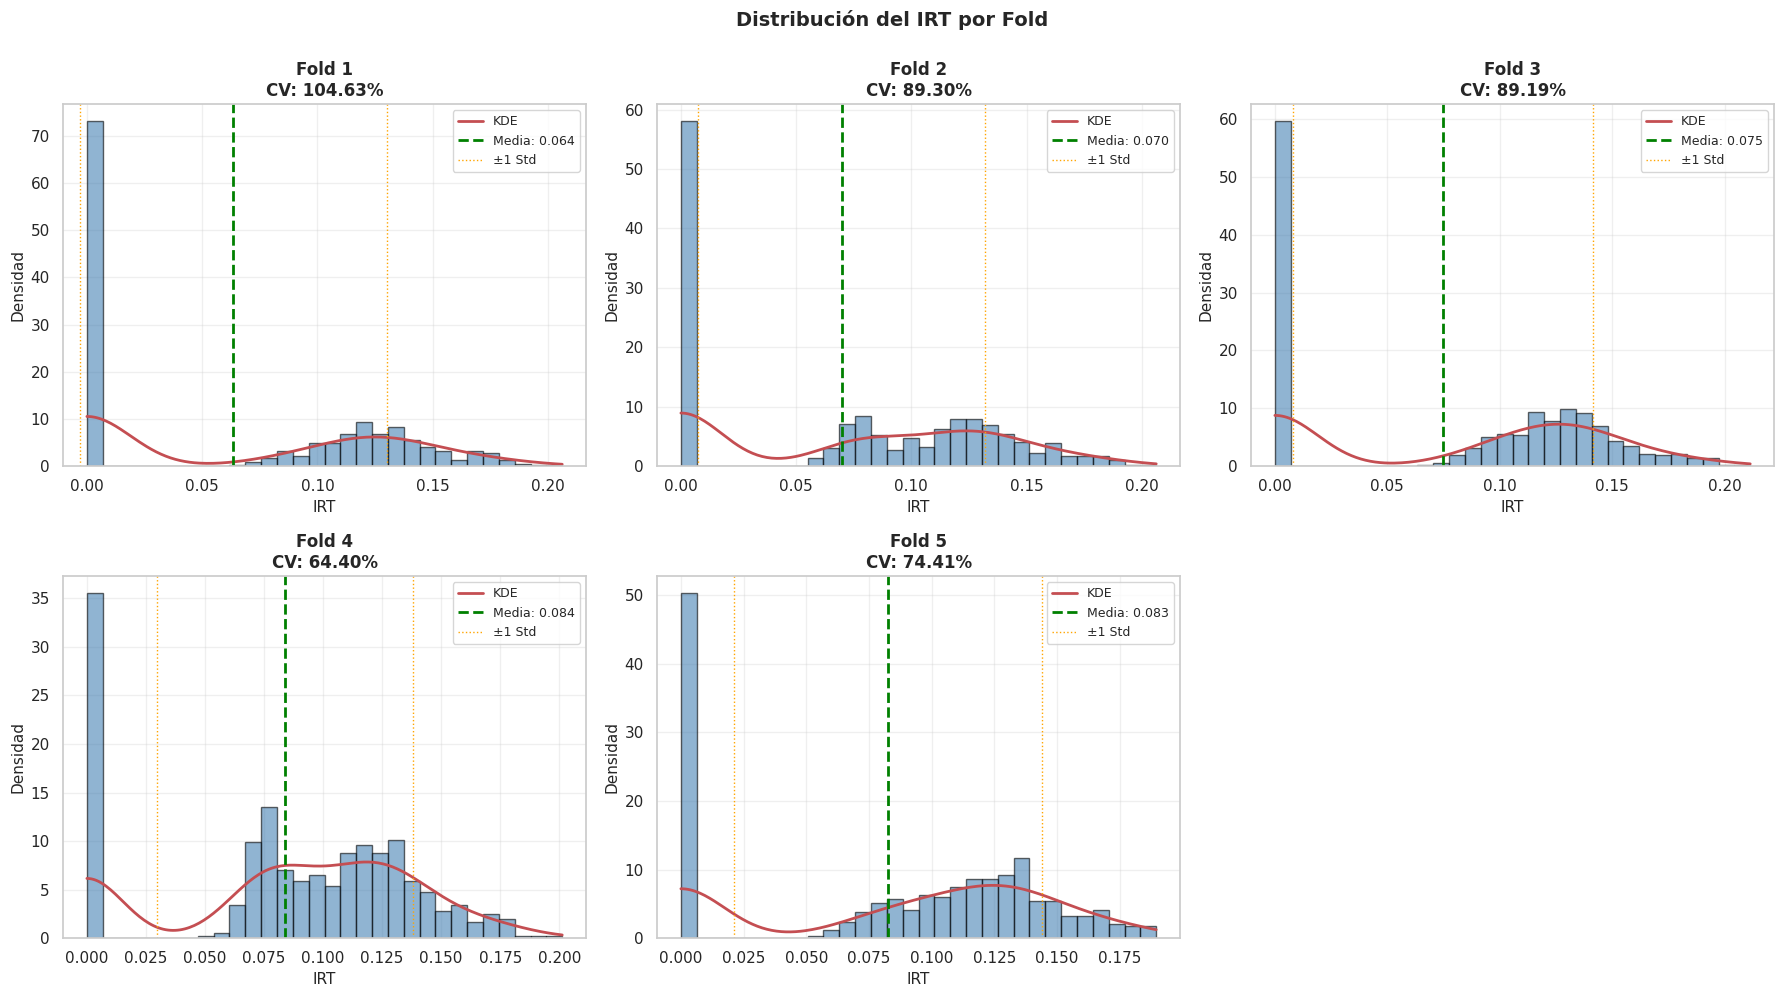

In [20]:
print("ANALISIS DE DISTRIBUCION DEL IRT POR FOLD")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for fold_idx, result in enumerate(FOLD_RESULTS):
    ax = axes[fold_idx]
    
    irt_values = result['irt_values']
    fold_num = result['fold']
    
    # Histograma
    ax.hist(irt_values, bins=30, alpha=0.6, color='steelblue', edgecolor='black', density=True)
    
    # KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(irt_values)
    x_range = np.linspace(irt_values.min(), irt_values.max(), 200)
    ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
    
    # Estadísticos
    ax.axvline(result['irt_mean'], color='green', linestyle='--', linewidth=2, label=f'Media: {result["irt_mean"]:.3f}')
    ax.axvline(result['irt_mean'] - result['irt_std'], color='orange', linestyle=':', linewidth=1, label=f'±1 Std')
    ax.axvline(result['irt_mean'] + result['irt_std'], color='orange', linestyle=':', linewidth=1)
    
    ax.set_xlabel('IRT', fontsize=11)
    ax.set_ylabel('Densidad', fontsize=11)
    ax.set_title(f'Fold {fold_num}\nCV: {result["irt_cv"]:.2%}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3)

# Eliminar subplot extra
axes[-1].axis('off')

plt.suptitle('Distribución del IRT por Fold', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()

output_fig = os.path.join(PLOTS_DIR, "irt_distribution_by_fold.png")
plt.savefig(output_fig, dpi=150, bbox_inches='tight')
print(f"✓ Guardado: {output_fig}")
plt.show()

print("="*80)

## 8. Análisis de Consistencia Espacial del IRT

Evaluamos si el IRT mantiene coherencia espacial entre folds analizando la correlación de valores IRT en píxeles compartidos.

In [22]:
print("ANALISIS DE CONSISTENCIA ESPACIAL DEL IRT ENTRE FOLDS")
print("="*80)

# Análisis de correlación entre folds en píxeles de train
# Crear tabla de comparación de métricas clave
consistency_metrics = []

for i, result_i in enumerate(FOLD_RESULTS):
    fold_i = result_i['fold']
    
    metrics_i = {
        'fold': fold_i,
        'irt_mean': result_i['irt_mean'],
        'irt_std': result_i['irt_std'],
        'silhouette': result_i['silhouette'],
        'ari_t585': result_i['ari_t585'],
        'avg_stability_t585': result_i['avg_stability_t585']
    }
    consistency_metrics.append(metrics_i)

df_consistency = pd.DataFrame(consistency_metrics)

# Calcular coeficiente de variación entre folds para cada métrica
cv_metrics = {}
for col in ['irt_mean', 'irt_std', 'silhouette', 'ari_t585', 'avg_stability_t585']:
    cv = (df_consistency[col].std() / df_consistency[col].mean()) * 100
    cv_metrics[col] = cv

print("\nCoeficiente de Variacion (CV%) entre folds:")
print("-" * 60)
for metric, cv in cv_metrics.items():
    status = "✓ BAJO" if cv < 10 else ("⚠ MEDIO" if cv < 20 else "✗ ALTO")
    print(f"  {metric:25s}: {cv:6.2f}%  {status}")

# Evaluar consistencia general
avg_cv = np.mean(list(cv_metrics.values()))
print(f"\n  Promedio CV:              {avg_cv:6.2f}%")

if avg_cv < 15:
    consistency_level = "ALTA - El modelo generaliza bien entre regiones"
elif avg_cv < 25:
    consistency_level = "MEDIA - Hay variabilidad moderada entre regiones"
else:
    consistency_level = "BAJA - Alta dependencia de la región específica"

print(f"\nConsistencia Global: {consistency_level}")
print("="*80)

ANALISIS DE CONSISTENCIA ESPACIAL DEL IRT ENTRE FOLDS

Coeficiente de Variacion (CV%) entre folds:
------------------------------------------------------------
  irt_mean                 :  11.48%  ⚠ MEDIO
  irt_std                  :   8.29%  ✓ BAJO
  silhouette               :  33.01%  ✗ ALTO
  ari_t585                 :  29.66%  ✗ ALTO
  avg_stability_t585       :  16.14%  ⚠ MEDIO

  Promedio CV:               19.72%

Consistencia Global: MEDIA - Hay variabilidad moderada entre regiones


## 9. Conclusiones y Análisis de Generalización

Resumen de resultados del análisis de validación cruzada espacial para VAE + SOM con k=3.

In [24]:
print("RESUMEN DE RESULTADOS: VALIDACION CRUZADA ESPACIAL")
print("="*80)
print(f"\nConfiguracion del Experimento:")
print(f"  Modelo:               {MODEL_KEY}")
print(f"  Metodo de clustering: {CLUSTERING_METHOD}")
print(f"  Numero de clusters:   {K_CLUSTERS}")
print(f"  Numero de folds:      {N_FOLDS}")
print(f"  Total de pixeles:     {N_PER_SCENARIO}")

print(f"\n{'='*80}")
print("METRICAS PROMEDIO ENTRE FOLDS (Media ± Std)")
print(f"{'='*80}\n")

# Clustering Interno
print("1. Calidad de Clustering Interno (BASE):")
print(f"  Silhouette Score:     {df_summary.loc[df_summary['Metrica']=='silhouette', 'Media'].values[0]:.4f} ± {df_summary.loc[df_summary['Metrica']=='silhouette', 'Std'].values[0]:.4f}")
print(f"  Calinski-Harabasz:    {df_summary.loc[df_summary['Metrica']=='calinski_harabasz', 'Media'].values[0]:.2f} ± {df_summary.loc[df_summary['Metrica']=='calinski_harabasz', 'Std'].values[0]:.2f}")
print(f"  Davies-Bouldin:       {df_summary.loc[df_summary['Metrica']=='davies_bouldin', 'Media'].values[0]:.4f} ± {df_summary.loc[df_summary['Metrica']=='davies_bouldin', 'Std'].values[0]:.4f}")
print(f"  Dunn Index:           {df_summary.loc[df_summary['Metrica']=='dunn_index', 'Media'].values[0]:.4f} ± {df_summary.loc[df_summary['Metrica']=='dunn_index', 'Std'].values[0]:.4f}")

# Estabilidad BASE → T585
print(f"\n2. Estabilidad BASE → T585:")
print(f"  ARI:                  {df_summary.loc[df_summary['Metrica']=='ari_t585', 'Media'].values[0]:.4f} ± {df_summary.loc[df_summary['Metrica']=='ari_t585', 'Std'].values[0]:.4f}")
print(f"  Avg Jaccard:          {df_summary.loc[df_summary['Metrica']=='avg_jaccard_t585', 'Media'].values[0]:.4f} ± {df_summary.loc[df_summary['Metrica']=='avg_jaccard_t585', 'Std'].values[0]:.4f}")
print(f"  Avg Drift:            {df_summary.loc[df_summary['Metrica']=='avg_drift_t585', 'Media'].values[0]:.4f} ± {df_summary.loc[df_summary['Metrica']=='avg_drift_t585', 'Std'].values[0]:.4f}")
print(f"  Avg Stability:        {df_summary.loc[df_summary['Metrica']=='avg_stability_t585', 'Media'].values[0]:.4f} ± {df_summary.loc[df_summary['Metrica']=='avg_stability_t585', 'Std'].values[0]:.4f}")

# IRT
print(f"\n3. Indice de Resiliencia Territorial (IRT):")
print(f"  IRT Mean:             {df_summary.loc[df_summary['Metrica']=='irt_mean', 'Media'].values[0]:.4f} ± {df_summary.loc[df_summary['Metrica']=='irt_mean', 'Std'].values[0]:.4f}")
print(f"  IRT Std:              {df_summary.loc[df_summary['Metrica']=='irt_std', 'Media'].values[0]:.4f} ± {df_summary.loc[df_summary['Metrica']=='irt_std', 'Std'].values[0]:.4f}")
print(f"  IRT CV:               {df_summary.loc[df_summary['Metrica']=='irt_cv', 'Media'].values[0]:.4f} ± {df_summary.loc[df_summary['Metrica']=='irt_cv', 'Std'].values[0]:.4f}")
print(f"  IRT IQR:              {df_summary.loc[df_summary['Metrica']=='irt_iqr', 'Media'].values[0]:.4f} ± {df_summary.loc[df_summary['Metrica']=='irt_iqr', 'Std'].values[0]:.4f}")

print(f"\n{'='*80}")
print("EVALUACION DE GENERALIZACION")
print(f"{'='*80}\n")

# Evaluación general
avg_cv_overall = df_summary['CV'].mean()
print(f"Coeficiente de Variacion Promedio: {avg_cv_overall:.2f}%\n")

if avg_cv_overall < 15:
    print("✓ EXCELENTE: El modelo generaliza de forma robusta entre regiones")
    print("  - Baja variabilidad entre folds")
    print("  - IRT mantiene coherencia espacial")
    print("  - Modelo confiable para aplicacion territorial")
elif avg_cv_overall < 25:
    print("⚠ ACEPTABLE: El modelo muestra variabilidad moderada")
    print("  - Hay diferencias regionales moderadas")
    print("  - IRT requiere calibracion por zona")
    print("  - Modelo util con ajustes locales")
else:
    print("✗ INSUFICIENTE: Alta dependencia regional")
    print("  - Fuerte variabilidad entre folds")
    print("  - IRT no es consistente espacialmente")
    print("  - Modelo no recomendado para generalizacion")

print(f"\n{'='*80}")

RESUMEN DE RESULTADOS: VALIDACION CRUZADA ESPACIAL

Configuracion del Experimento:
  Modelo:               VAE
  Metodo de clustering: SOM
  Numero de clusters:   3
  Numero de folds:      5
  Total de pixeles:     661

METRICAS PROMEDIO ENTRE FOLDS (Media ± Std)

1. Calidad de Clustering Interno (BASE):
  Silhouette Score:     0.2327 ± 0.0768
  Calinski-Harabasz:    174.66 ± 52.13
  Davies-Bouldin:       1.6815 ± 0.4447
  Dunn Index:           0.1489 ± 0.0370

2. Estabilidad BASE → T585:
  ARI:                  0.3279 ± 0.0973
  Avg Jaccard:          0.4779 ± 0.1059
  Avg Drift:            1.4701 ± 0.0191
  Avg Stability:        0.6248 ± 0.1008

3. Indice de Resiliencia Territorial (IRT):
  IRT Mean:             0.0749 ± 0.0086
  IRT Std:              0.0622 ± 0.0052
  IRT CV:               0.8438 ± 0.1546
  IRT IQR:              0.1158 ± 0.0296

EVALUACION DE GENERALIZACION

Coeficiente de Variacion Promedio: 20.59%

⚠ ACEPTABLE: El modelo muestra variabilidad moderada
  - Hay difere